In [1]:
import pandas as pd
pd.options.display.float_format = '{:,.2f}'.format  # Display with comma separators and 2 decimal places


In [2]:
df = pd.read_csv("synthetic_customer_churn_data.csv")
df

,account_id,product_id,txn_amt,date_id,txn_flow
0,1675009,14,395.39,6172,debit
1,1006123,28,409.89,6181,debit
2,1936846,74,56.50,6450,debit
3,1542862,104,43.09,6370,debit
4,1648106,97,849.56,6154,debit
...,...,...,...,...,...
9999995,1102857,21,281.49,6617,debit
9999996,1899285,86,799.01,6195,debit
9999997,1807224,65,121.67,6179,debit
9999998,1046974,96,143.07,6055,debit


In [3]:
max_date_id = df["date_id"].max()
max_date_id

6729

### Let's explore churn

Assumption(bank side) : A customer is called churn if he/she is inactive for atleast 30 days

Initially we create segment's based on 30 days durations<br>
segment1 : Initial 30 days<br>
segment2 : 31-60 days<br>
segment3 : 61-90 days<br>
segment4 : 91-120 days (optional)

based on transaction pattern obtained from segment2 and segment3 we try to predict if account will be active in segment1 

In [4]:
duration = 30
segment1 = max_date_id - duration
segment2 = segment1 - duration
segment3 = segment2 - duration

print(f" days : {max_date_id= },{segment1=},{segment2=},{segment3=}")

 days : max_date_id= 6729,segment1=6699,segment2=6669,segment3=6639


In [5]:
df_recent = df.loc[(df.date_id >= segment3) & (df.date_id <= max_date_id)]
df_recent.head()

,account_id,product_id,txn_amt,date_id,txn_flow
6,1492103,29,931.67,6704,debit
14,1219814,91,34.71,6651,debit
20,1263226,54,927.72,6667,debit
21,1357131,55,997.18,6671,debit
39,1555229,39,646.28,6653,debit


In [6]:
df_recent["segment"] = pd.cut(x=df_recent.date_id,bins=[segment3,segment2,segment1,max_date_id],labels=[3,2,1],include_lowest=False
                              )
df_recent

/tmp/ipykernel_15544/2290748173.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_recent["segment"] = pd.cut(x=df_recent.date_id,bins=[segment3,segment2,segment1,max_date_id],labels=[3,2,1],include_lowest=False


,account_id,product_id,txn_amt,date_id,txn_flow,segment
6,1492103,29,931.67,6704,debit,1
14,1219814,91,34.71,6651,debit,3
20,1263226,54,927.72,6667,debit,3
21,1357131,55,997.18,6671,debit,2
39,1555229,39,646.28,6653,debit,3
...,...,...,...,...,...,...
9999949,1729595,10,248.61,6640,debit,3
9999973,1586878,103,422.78,6668,debit,3
9999977,1160790,92,322.27,6666,debit,3
9999979,1237932,31,868.18,6703,debit,1


In [7]:
df_recent.groupby("segment").agg(min_value = ("date_id","min"),max_value=("date_id","max"),accounts=("account_id","nunique"))

,min_value,max_value,accounts
segment,,,
3,6640,6669,336291
2,6670,6699,336032
1,6700,6729,337509


In [8]:
facts = df_recent.groupby(by=["account_id","segment","txn_flow"]).agg(txn_cnt=("account_id","count"),txn_amt=("txn_amt","sum")).reset_index()
facts.head(10)

,account_id,segment,txn_flow,txn_cnt,txn_amt
0,1000000,3,credit,0,0.00
1,1000000,3,debit,0,0.00
2,1000000,3,services,0,0.00
3,1000000,2,credit,0,0.00
4,1000000,2,debit,0,0.00
5,1000000,2,services,0,0.00
6,1000000,1,credit,0,0.00
7,1000000,1,debit,1,54.93
8,1000000,1,services,0,0.00
9,1000003,3,credit,0,0.00


In [28]:
additional_facts = facts.query("segment in (2,3)").pivot(index="account_id",columns=["segment","txn_flow"],values=["txn_cnt","txn_amt"])
additional_facts.reset_index(inplace=True)
additional_facts

account_id txn_cnt                                      txn_amt  \
segment                   3                     2                      3   
txn_flow             credit debit services credit debit services  credit   
0           1000000    0.00  0.00     0.00   0.00  0.00     0.00    0.00   
1           1000003    0.00  0.00     0.00   0.00  1.00     1.00    0.00   
2           1000005    0.00  0.00     0.00   0.00  1.00     0.00    0.00   
3           1000006    0.00  0.00     0.00   1.00  0.00     0.00    0.00   
4           1000007    0.00  1.00     0.00   0.00  0.00     0.00    0.00   
...             ...     ...   ...      ...    ...   ...      ...     ...   
711890      1999994    0.00  0.00     0.00   0.00  0.00     0.00    0.00   
711891      1999995    1.00  0.00     0.00   0.00  0.00     0.00   74.04   
711892      1999996    0.00  0.00     0.00   1.00  0.00     0.00    0.00   
711893      1999997    0.00  0.00     0.00   0.00  0.00     0.00    0.00   
711894      1999998    0.00  0.00     1.00   0.00  0.00     0.00    0.00   

                                                 
segment                       2                  
txn_flow  debit services credit  debit services  
0          0.00     0.00   0.00   0.00     0.00  
1          0.00     0.00   0.00 233.94   843.25  
2          0.00     0.00   0.00 128.85     0.00  
3          0.00     0.00  72.60   0.00     0.00  
4        969.20     0.00   0.00   0.00     0.00  
...         ...      ...    ...    ...      ...  
711890     0.00     0.00   0.00   0.00     0.00  
711891     0.00     0.00   0.00   0.00     0.00  
711892     0.00     0.00 625.19   0.00     0.00  
711893     0.00     0.00   0.00   0.00     0.00  
711894     0.00   746.76   0.00   0.00     0.00  

[711895 rows x 13 columns]

In [29]:
additional_facts.columns = ['_'.join(filter(None, map(str, col))) for col in additional_facts.columns]
additional_facts

,account_id,txn_cnt_3_credit,txn_cnt_3_debit,txn_cnt_3_services,txn_cnt_2_credit,txn_cnt_2_debit,txn_cnt_2_services,txn_amt_3_credit,txn_amt_3_debit,txn_amt_3_services,txn_amt_2_credit,txn_amt_2_debit,txn_amt_2_services
0,1000000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,1000003,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,233.94,843.25
2,1000005,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,128.85,0.00
3,1000006,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,72.60,0.00,0.00
4,1000007,0.00,1.00,0.00,0.00,0.00,0.00,0.00,969.20,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
711890,1999994,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
711891,1999995,1.00,0.00,0.00,0.00,0.00,0.00,74.04,0.00,0.00,0.00,0.00,0.00
711892,1999996,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,625.19,0.00,0.00
711893,1999997,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [30]:
additional_facts.to_parquet("result/facts/additional_fact.parquet")

In [9]:
mapping_txn_flow = {"not_present":0,"credit":1,"debit":2,"services":3,"credit_debit":4,"credit_services":5,"debit_services":6,"credit_debit_service":7}
master_txn_flow = pd.DataFrame(mapping_txn_flow.items(),columns=["txn_flow_name","id"])
master_txn_flow


,txn_flow_name,id
0,not_present,0
1,credit,1
2,debit,2
3,services,3
4,credit_debit,4
5,credit_services,5
6,debit_services,6
7,credit_debit_service,7


In [10]:
facts_p = facts.pivot(index=["account_id","segment"],columns=["txn_flow"],values=["txn_cnt"])
facts_p.columns = facts_p.columns.droplevel(0)  # Drop the first level ('txn_cnt')
facts_p.columns.name=None
facts_p = facts_p.reset_index()
facts_p


,account_id,segment,credit,debit,services
0,1000000,3,0,0,0
1,1000000,2,0,0,0
2,1000000,1,0,1,0
3,1000003,3,0,0,0
4,1000003,2,0,1,1
...,...,...,...,...,...
2135680,1999997,2,0,0,0
2135681,1999997,1,0,1,0
2135682,1999998,3,0,0,1
2135683,1999998,2,0,0,0


In [11]:
import numpy as np

cond1 = (facts_p["credit"] >= 1) & (facts_p["debit"] ==0) & (facts_p["services"] == 0)
cond2 = (facts_p["credit"] == 0) & (facts_p["debit"] >= 1) & (facts_p["services"] == 0)
cond3 = (facts_p["credit"] ==0) & (facts_p["debit"] == 0) & (facts_p["services"] >= 1)

cond4 = (facts_p["credit"] >= 1) & (facts_p["debit"] >= 1) & (facts_p["services"] == 0)
cond5 = (facts_p["credit"] >= 1) & (facts_p["debit"] == 0) & (facts_p["services"] >= 1)
cond6 = (facts_p["credit"] == 0) & (facts_p["debit"] >= 1) & (facts_p["services"] >= 1)

cond7 = (facts_p["credit"] >= 1) & (facts_p["debit"] >= 1) & (facts_p["services"] >= 1)



# Apply conditions vectorized
facts_p["txn_flow"] = np.select(
    [cond1, cond2, cond3,cond4,cond5,cond6,cond7],  # Conditions
    ["1", "2", "3","4","5","6","7"],  # Corresponding Values
    default="0"  # Default value if none match
)
facts_p

,account_id,segment,credit,debit,services,txn_flow
0,1000000,3,0,0,0,0
1,1000000,2,0,0,0,0
2,1000000,1,0,1,0,2
3,1000003,3,0,0,0,0
4,1000003,2,0,1,1,6
...,...,...,...,...,...,...
2135680,1999997,2,0,0,0,0
2135681,1999997,1,0,1,0,2
2135682,1999998,3,0,0,1,3
2135683,1999998,2,0,0,0,0


In [12]:
final_facts = facts_p.pivot(index="account_id",columns="segment",values="txn_flow")
final_facts.columns.name=None
final_facts.reset_index(inplace=True)
final_facts.columns = ["account_id","3","2","1"]
final_facts = final_facts.rename(columns={"1":"current","2":"last","3":"second_last"})

final_facts["current"] = final_facts["current"].astype("int")

final_facts["last"] = final_facts["last"].astype("str")
final_facts["second_last"] = final_facts["second_last"].astype("str")


final_facts["seq"] = final_facts["second_last"]+final_facts["last"]
final_facts["seq"] = final_facts["seq"].astype("str")
final_facts["is_churn"] = (final_facts["current"]==0).astype("int")
final_facts

,account_id,second_last,last,current,seq,is_churn
0,1000000,0,0,2,00,0
1,1000003,0,6,0,06,1
2,1000005,0,2,0,02,1
3,1000006,0,1,0,01,1
4,1000007,2,0,2,20,0
...,...,...,...,...,...,...
711890,1999994,0,0,6,00,0
711891,1999995,1,0,0,10,1
711892,1999996,0,1,0,01,1
711893,1999997,0,0,2,00,0


In [14]:
final_facts.to_parquet("result/facts/txn_flow_fact.parquet")

### Reading churn sequence of master data from analysis

In [38]:
master = pd.read_parquet("result/churn_eda_master.parquet")
master

,second_last,last,seq,not_churn,churn,total_accounts,churn_percentage,cummulative_churn_acc,cummulative_churn_per
0,not_present,credit_debit_service,07,362,756,1118,67.62,756,0.20
1,not_present,credit_services,05,1584,3293,4877,67.52,4049,1.08
2,debit,debit_services,26,636,1300,1936,67.15,5349,1.42
3,debit,credit,21,4309,8797,13106,67.12,14146,3.76
4,debit,debit,22,7435,15165,22600,67.10,29311,7.79
5,debit_services,credit,61,369,749,1118,66.99,30060,7.99
6,services,debit,32,2819,5719,8538,66.98,35779,9.51
7,services,not_present,30,12582,25313,37895,66.80,61092,16.24
8,credit,credit,11,2502,5016,7518,66.72,66108,17.57
9,services,services,33,1069,2143,3212,66.72,68251,18.14


In [21]:
churn_seq = list(master['seq'])
final_facts["predicted_churn"] = (final_facts.seq.isin(churn_seq)).astype("int")
final_facts

,account_id,second_last,last,current,seq,is_churn,predicted_churn
0,1000000,0,0,2,00,0,0
1,1000003,0,6,0,06,1,0
2,1000005,0,2,0,02,1,1
3,1000006,0,1,0,01,1,1
4,1000007,2,0,2,20,0,1
...,...,...,...,...,...,...,...
711890,1999994,0,0,6,00,0,0
711891,1999995,1,0,0,10,1,1
711892,1999996,0,1,0,01,1,1
711893,1999997,0,0,2,00,0,0


In [22]:
final_facts.query("is_churn==1")["account_id"].count()

374386

In [24]:
final_facts.query("predicted_churn==1")["account_id"].count()

510471

In [25]:
final_facts.query("is_churn==1 and predicted_churn==1")["account_id"].count()

338012

In [ ]:
final_facts.query("is_churn==1 and predicted_churn==1")["account_id"].count()

              precision    recall  f1-score   support

   not-churn       0.82      0.49      0.61    337509
       churn       0.66      0.90      0.76    374386

    accuracy                           0.71    711895
   macro avg       0.74      0.70      0.69    711895
weighted avg       0.74      0.71      0.69    711895

roc_auc_score : 0.6959337928169551
confusion_matrix : [[165050 172459]
 [ 36374 338012]]


<Axes: >

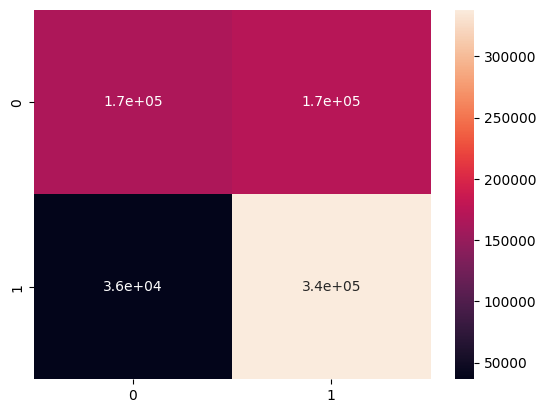

In [37]:
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score
cr = classification_report(final_facts["is_churn"],final_facts["predicted_churn"],target_names=["not-churn","churn"])
print(cr)

roc_score = roc_auc_score(final_facts["is_churn"],final_facts["predicted_churn"])
print(f"roc_auc_score : {roc_score}")
cf_matrix = confusion_matrix(final_facts["is_churn"],final_facts["predicted_churn"])
import seaborn as sns
print(f"confusion_matrix : {cf_matrix}")
sns.heatmap(cf_matrix, annot=True)